# Corr_2PCF: Section 4.3.1 Companion Notebook

This compact notebook keeps only the 2PCF demonstrations that match the paper narrative:

1. isotropic 2PCFs from thin-shell, thick-shell, and Gaussian-shell binning windows;
2. comparison with traditional binned estimators (`pycorr`/`TreeCorr`) using precomputed benchmark curves;
3. custom anisotropic binning windows built from projected factors, including the Gaussian-ring example used in the paper.

The older exploratory examples such as cosine isotropic windows and disk/cylinder/cylshell scans are intentionally left out here.

In [1]:

from pathlib import Path
import copy
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
from numba import njit

from pyhermes.io import Corr2PCFData, SFCField, WindowFunc
from pyhermes.utils.plot import plot_corr2pcf_2d
from pyhermes.param.parambase import read_param
from pyhermes.theory.corr2pcf import Corr_2PCF, build_binning_window_params_for_sample
from pyhermes.utils.special_functions import jn_numba
from pyhermes.utils.window_functions import window_function_sphere_numba

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "examples":
    PROJECT_ROOT = cwd.parent.parent
elif cwd.name == "examples":
    PROJECT_ROOT = cwd.parent
elif (cwd / "examples").exists():
    PROJECT_ROOT = cwd
else:
    raise RuntimeError("Run this notebook from the project root or examples/notebooks.")

EXAMPLES_DIR = PROJECT_ROOT / "examples"
OUTPUT_DIR = EXAMPLES_DIR / "output"
FIGS_DIR = EXAMPLES_DIR / "figs"
TEST_OUTPUT_DIR = PROJECT_ROOT / "tests" / "output"
FIGS_DIR.mkdir(exist_ok=True)

os.chdir(EXAMPLES_DIR)

THREADS = 8
SFC_PATH = OUTPUT_DIR / "quijote8000_snap004_sfc.pkl"
RSD_SFC_PATH = OUTPUT_DIR / "quijote8000_snap004_rsd_sfc.pkl"

STYLE = {
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 17,
    "axes.titlesize": 17,
    "legend.fontsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.grid": False,
}
COLORS = {"blue": "#1f77b4", "orange": "#ff7f0e", "green": "#2ca02c"}
plt.rcParams.update(STYLE)

print(f"project root: {PROJECT_ROOT}")
print(f"output dir  : {OUTPUT_DIR}")


project root: /Users/xutengpeng/xutp/PycharmProjects/PyHermes
output dir  : /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output


## 1. Isotropic 2PCF: thin shell, thick shell, and Gaussian shell

The thin shell is the elementary isotropic binning window. A finite-width shell can be assembled as a normalized difference of two spheres, and a Gaussian shell replaces the sharp radial bin with a smooth radial profile. These examples run directly in the notebook because they only evaluate a one-dimensional sampling grid.

In [2]:
@njit
def window_function_thick_shell_numba(ki, kj, kk, R_in, R_out):
    V_in = R_in ** 3
    V_out = R_out ** 3
    denom = V_out - V_in
    if denom == 0.0:
        k = np.sqrt(ki * ki + kj * kj + kk * kk)
        q = 2.0 * np.pi * k * R_out
        if q == 0.0:
            return 1.0
        return np.sin(q) / q

    W_in = window_function_sphere_numba(ki, kj, kk, R_in)
    W_out = window_function_sphere_numba(ki, kj, kk, R_out)
    return (W_out * V_out - W_in * V_in) / denom


def make_thick_shell_binning_window(delta_R):
    def mapping_s_to_thick_shell(sample, binning_window):
        params = copy.deepcopy(binning_window)
        s = float(sample["s"])
        params["len_args"]["R_in"] = max(s - 0.5 * delta_R, 0.0)
        params["len_args"]["R_out"] = s + 0.5 * delta_R
        return params

    return {
        "type": "thick_shell",
        "func": window_function_thick_shell_numba,
        "len_args": ["R_in", "R_out"],
        "mapping": mapping_s_to_thick_shell,
        "kernel_mode": "octant",
    }


def make_gaussian_shell_binning_window(R_smooth):
    def mapping_s_to_gaussian_shell(sample, binning_window):
        params = copy.deepcopy(binning_window)
        params["len_args"]["R_shell"] = float(sample["s"])
        params["len_args"]["R_smooth"] = float(R_smooth)
        return params

    return {
        "type": "gaussian_shell",
        "len_args": ["R_shell", "R_smooth"],
        "mapping": mapping_s_to_gaussian_shell,
        "kernel_mode": "octant",
    }


def run_isotropic_xi_s(binning_window, s_values, threads=THREADS):
    task = Corr_2PCF()
    task.sfc_field1 = str(SFC_PATH)
    task.sfc_field2 = str(SFC_PATH)
    task.random1 = "uniform"
    task.random2 = "uniform"
    task.binning_window = copy.deepcopy(binning_window)
    task.sampling["s"] = np.asarray(s_values, dtype=float)
    task.products = "xi"
    task.threads = threads
    return task.run(save_result=False)

In [3]:
s_values = np.linspace(5.0, 150.0, 30)

iso_curves = {
    "thin shell": run_isotropic_xi_s("shell", s_values),
    r"thick shell ($\Delta R=5$)": run_isotropic_xi_s(make_thick_shell_binning_window(5.0), s_values),
    r"Gaussian shell ($\sigma_R=5$)": run_isotropic_xi_s(make_gaussian_shell_binning_window(5.0), s_values),
    r"thick shell ($\Delta R=10$)": run_isotropic_xi_s(make_thick_shell_binning_window(10.0), s_values),
    r"Gaussian shell ($\sigma_R=10$)": run_isotropic_xi_s(make_gaussian_shell_binning_window(10.0), s_values),
}

17:33:54 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Field weight normalization rule | task weight_normalization=catalog | catalog fields are converted to the task rule; derived fields are used as-is except for task='unit'.
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=30, min=5.0, max=150.0, source=explicit array, threads=8
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
17:33:54 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Binning window: type=shell | mapping=s_to_R | kernel_mode=octant
17:33:54 - INFO - pyhermes.io.base:SFCField - Reading SFCField dat

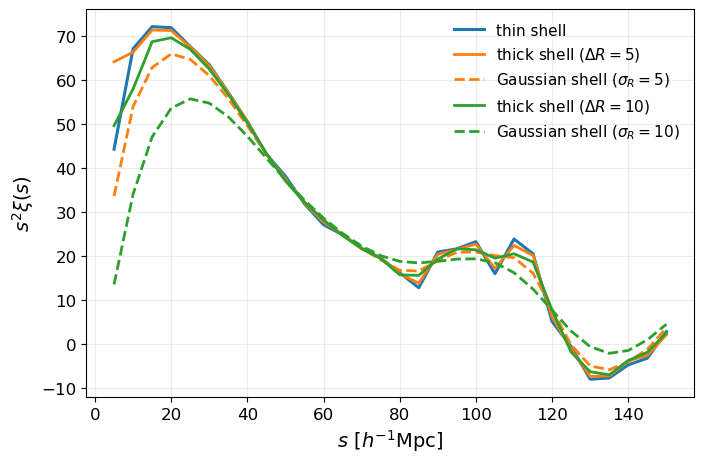

In [4]:

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    styles = {
        "thin shell": dict(color="0.20", ls="-", lw=2.4),
        r"thick shell ($\Delta R=5$)": dict(color=COLORS["blue"], ls="-", lw=2.2),
        r"Gaussian shell ($\sigma_R=5$)": dict(color=COLORS["blue"], ls="--", lw=2.2),
        r"thick shell ($\Delta R=10$)": dict(color=COLORS["orange"], ls="-", lw=2.2),
        r"Gaussian shell ($\sigma_R=10$)": dict(color=COLORS["orange"], ls="--", lw=2.2),
    }
    for label, data in iso_curves.items():
        ax.plot(data.s, data.s ** 2 * data.xi, label=label, **styles[label])

    ax.set_xlabel(r"$s\ [h^{-1}\mathrm{Mpc}]$")
    ax.set_ylabel(r"$s^2\xi(s)$")
    ax.grid(False)
    ax.legend(frameon=False, ncol=1)
    ax.tick_params(direction="in", top=True, right=True, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(FIGS_DIR / "corr2pcf_binning_window_shell_gaussian_shell_comparison.png", dpi=240, bbox_inches="tight")
    plt.show()


## 2. Isotropic benchmark curves

The following cell uses the benchmark curves already produced by the comparison script. PyHermes samples the continuous binning-window estimator at the chosen radii, while `pycorr` and `TreeCorr` use traditional finite bins; matching the bin width and the sampling centers makes the large-scale curves directly comparable.

In [5]:
def find_existing(*paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    raise FileNotFoundError("None of the candidate files exists: " + ", ".join(map(str, paths)))

benchmark_path = find_existing(
    OUTPUT_DIR / "benchmark_2pcf_isotropic_s2xi_curves.npz",
    TEST_OUTPUT_DIR / "benchmark_2pcf_isotropic_s2xi_curves.npz",
)
bench = np.load(benchmark_path)
print(f"loaded benchmark curves from {benchmark_path}")

loaded benchmark curves from /Users/xutengpeng/xutp/PycharmProjects/PyHermes/tests/output/benchmark_2pcf_isotropic_s2xi_curves.npz


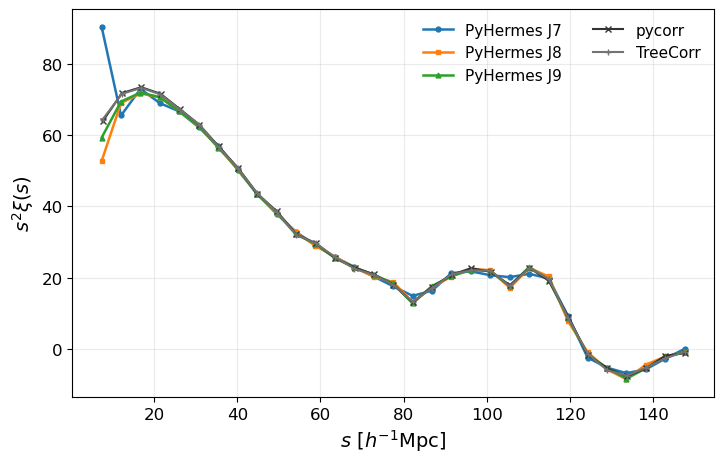

In [6]:

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    pyh_styles = {
        "PyHermes_J7": dict(color=COLORS["blue"], marker="o", ms=4.2, lw=2.0),
        "PyHermes_J8": dict(color=COLORS["orange"], marker="s", ms=4.2, lw=2.0),
        "PyHermes_J9": dict(color=COLORS["green"], marker="^", ms=4.2, lw=2.0),
    }
    for name, style in pyh_styles.items():
        s = bench[f"{name}_s"]
        xi = bench[f"{name}_xi"]
        ax.plot(s, s ** 2 * xi, label=name.replace("_", " "), **style)

    for name, color, marker, ls in [("pycorr", "0.20", "x", "--"), ("TreeCorr", "0.45", "+", ":")]:
        s = bench[f"{name}_s"]
        xi = bench[f"{name}_xi"]
        ax.plot(s, s ** 2 * xi, color=color, marker=marker, ms=5.0, lw=1.9, ls=ls, label=name)

    ax.axhline(0.0, color="0.70", lw=0.9, zorder=0)
    ax.set_xlabel(r"$s\ [h^{-1}\mathrm{Mpc}]$")
    ax.set_ylabel(r"$s^2\xi(s)\ [(h^{-1}\mathrm{Mpc})^2]$")
    ax.grid(False)
    ax.legend(frameon=False, ncol=2)
    ax.tick_params(direction="in", top=True, right=True, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(FIGS_DIR / "benchmark_2pcf_isotropic_s2xi_curves.png", dpi=240, bbox_inches="tight")
    plt.show()


## 3. Custom anisotropic binning windows

For the redshift-space 2PCF, the usual ring window can be factored into a transverse part and a line-of-sight part. The Gaussian-ring variant uses the same line-of-sight factor but multiplies the transverse ring by a Gaussian factor. This cell demonstrates both custom window definitions and window multiplication.

In [7]:
@njit
def kernel_ring_2d(ki, kj, kk, R):
    k_perp = np.sqrt(ki * ki + kj * kj)
    return jn_numba(0, 2.0 * np.pi * k_perp * R)


@njit
def kernel_gauss_2d(ki, kj, kk, sigma_perp):
    k_perp = np.sqrt(ki * ki + kj * kj)
    q = 2.0 * np.pi * k_perp * sigma_perp
    return np.exp(-0.5 * q * q)


@njit
def kernel_double_delta_1d(ki, kj, kk, H):
    return np.cos(2.0 * np.pi * kk * H)


reference_field = SFCField(data_path=str(RSD_SFC_PATH), threads=THREADS)
R_demo = 30.0
H_demo = 20.0
sigma_demo = 5.0

W_ring_2d = WindowFunc(
    {"type": "ring_2d", "func": kernel_ring_2d, "len_args": {"R": R_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)
W_gauss_2d = WindowFunc(
    {"type": "gauss_2d", "func": kernel_gauss_2d, "len_args": {"sigma_perp": sigma_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)
W_los_1d = WindowFunc(
    {"type": "double_delta_1d", "func": kernel_double_delta_1d, "len_args": {"H": H_demo}, "kernel_mode": "octant"},
    reference_field.sfc_info,
    threads=THREADS,
)

W_ring_3d = W_ring_2d * W_los_1d
W_gauss_ring_3d = W_ring_2d * W_gauss_2d * W_los_1d
print("Constructed W_ring_3d and W_gauss_ring_3d from lower-dimensional factors.")

17:35:20 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_sfc.pkl <---
17:35:20 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.522e-06, Max = 1.761e-05, Mean = 5.96e-08, Sum = 1
Constructed W_ring_3d and W_gauss_ring_3d from lower-dimensional factors.


In [8]:
class Corr2PCFGaussianRing(Corr_2PCF):
    __module__ = Corr_2PCF.__module__

    def __init__(self, param_task=None, sigma_perp=5.0):
        if param_task is None:
            param_task = {"Corr_2PCF": {}}
        self.task_name = "Corr_2PCF"
        self.sigma_perp = float(sigma_perp)
        super(Corr_2PCF, self).__init__(param_task=param_task)
        self.format_params()
        self._fields_prepared = False

    def _build_binning_window_for_sample(self, sample, reference_field):
        ring_params = build_binning_window_params_for_sample(sample, self.binning_window)
        radius = float(ring_params["len_args"]["R"])
        half_height = float(ring_params["len_args"]["H"])

        W_ring = WindowFunc(
            {"type": "ring_2d", "func": kernel_ring_2d, "len_args": {"R": radius}, "kernel_mode": "octant"},
            reference_field.sfc_info,
            threads=self.threads,
        )
        W_gauss = WindowFunc(
            {"type": "gauss_2d", "func": kernel_gauss_2d, "len_args": {"sigma_perp": self.sigma_perp}, "kernel_mode": "octant"},
            reference_field.sfc_info,
            threads=self.threads,
        )
        W_los = WindowFunc(
            {"type": "double_delta_1d", "func": kernel_double_delta_1d, "len_args": {"H": half_height}, "kernel_mode": "octant"},
            reference_field.sfc_info,
            threads=self.threads,
        )
        return W_ring * W_gauss * W_los

The next cell can regenerate the anisotropic results if needed. By default it only reads the existing output files, because the RSD grids are usually produced once and then reused for plotting.

In [9]:
RUN_RSD_TASKS = False

ring_output = OUTPUT_DIR / "quijote8000_snap004_rsd_2pcf_smu.pkl"
gauss_ring_output = OUTPUT_DIR / "quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl"

if RUN_RSD_TASKS or not ring_output.exists():
    params = read_param(config_path="./configs/param_2pcf_smu.yaml")
    params = copy.deepcopy(params)
    params["Corr_2PCF"]["binning_window"] = "ring"
    params["Corr_2PCF"]["fout_path"] = str(ring_output)
    Corr_2PCF(params).run(overwrite=True)

if RUN_RSD_TASKS or not gauss_ring_output.exists():
    params = read_param(config_path="./configs/param_2pcf_smu.yaml")
    params = copy.deepcopy(params)
    params["Corr_2PCF"]["binning_window"] = "ring"
    params["Corr_2PCF"]["fout_path"] = str(gauss_ring_output)
    Corr2PCFGaussianRing(params, sigma_perp=5.0).run(overwrite=True)

print(ring_output, ring_output.exists())
print(gauss_ring_output, gauss_ring_output.exists())

/Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu.pkl True
/Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl True


## 4. RSD 2PCF: ring versus Gaussian ring

The plotted quantity is \(\log(1+\xi)\). The two panels use the same color scale and contour levels so that the response to the transverse Gaussian factor can be read directly.

17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu.pkl <---
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/quijote8000_snap004_rsd_2pcf_smu_gaussian_ring_sigma5.pkl <---
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
17:35:50 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


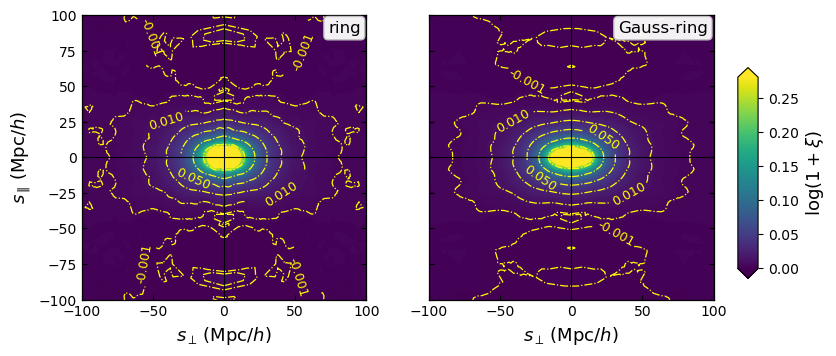

In [10]:
corr_ring = Corr2PCFData(data_path=str(ring_output), threads=THREADS)
corr_gauss_ring = Corr2PCFData(data_path=str(gauss_ring_output), threads=THREADS)

plot_kwargs = dict(
    s_min=0.0,
    add_contour=True,
    value="log10_1p_xi",
    cmap="viridis",
    vmin=-0.0005,
    vmax=0.28,
    n_levels=121,
    contour_levels=[-0.001, 0.003, 0.010, 0.025, 0.050, 0.100, 0.200],
    contour_kwargs={"colors": "yellow", "linewidths": 0.9, "linestyles": "dashdot"},
    center_line_kwargs={"color": "black", "lw": 0.8, "alpha": 0.95, "zorder": 20},
    label_fontsize=13,
    tick_fontsize=10,
    text_fontsize=12,
    spine_linewidth=0.9,
)

fig, axes = plt.subplots(1, 2, figsize=(8.1, 3.9), sharex=True, sharey=True)
fig.subplots_adjust(left=0.08, right=0.86, bottom=0.15, top=0.93, wspace=0.22)

for ax, corr, label in zip(axes, [corr_ring, corr_gauss_ring], ["ring", "Gauss-ring"]):
    plot_corr2pcf_2d(corr, ax=ax, label1=label, add_colorbar=False, **plot_kwargs)
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    ax.set_aspect("equal")

axes[1].set_ylabel("")
axes[1].tick_params(labelleft=False)

norm = mcolors.Normalize(vmin=plot_kwargs["vmin"], vmax=plot_kwargs["vmax"])
sm = cm.ScalarMappable(norm=norm, cmap=plot_kwargs["cmap"])
sm.set_array([])
cax = fig.add_axes([0.89, 0.23, 0.025, 0.54])
cbar = fig.colorbar(sm, cax=cax, orientation="vertical", extend="both")
cbar.set_label(r"$\log(1+\xi)$", fontsize=13)
cbar.ax.tick_params(labelsize=10)

fig.savefig(FIGS_DIR / "corr2pcf_ring_gaussian_ring_smu.png", dpi=240, bbox_inches="tight")
plt.show()

## Notes

- The isotropic part is meant to be executable as-is on a local machine with the standard example SFC field.
- The anisotropic part defines lightweight custom-window tasks, but the default plotting path reads existing results from `examples/output`.
- This notebook is intended to replace the exploratory bulk of the older `corr2pcf.ipynb` once the figures and text are finalized.